# 28_model_ensemble_JIW

- 목적: 시계열 예측 모델(관점 A)과 통계 모델(관점 B)을 결합해 **오경보와 미탐을 함께 줄이는 2단계 경보**를 검증한다. 설계: `docs/design_JIW.md`, `docs/final_design_JIW.md` §3.
- 입력: 24·25·26 노트북의 저장된 가중치(CNN·LSTM-AD·MTAD-GAT·MCD[amp]), `data/processed/11_window_features.parquet`. **새로 학습하지 않는다.**
- 출력: `figures/28_model_ensemble_JIW/`, `results/28_model_ensemble_JIW/`(metrics.csv · cv_scores.csv · error_cases.csv · bootstrap.csv · scores.csv)
- 담당: JIW
- 탐지 대상: 유압펌프 모터-펌프 구동부 이상 (센서 부착 부위를 확정할 수 없어 펌프/모터 원인은 구분하지 않는다)
- 심사 대응: 2번(결합 모델 비교), 3번(FP 운전 상태·FN 조건), 4번(주의/경보 단계 운영), 5번(두 관점 결합)
- 근거 표기: **[데이터]** 이 노트북 출력으로 확인 / **[추정]** 논리적으로 따라오나 미검증

## 검증하려는 가설 (설계서 H1~H5)

| # | 가설 | 성공 기준 |
|---|---|---|
| H1 | AND 결합의 오경보 감소가 시드·fold와 무관하게 재현된다 | 단독 대비 세그먼트 오경보 차이의 95% 부트스트랩 구간이 0 미만 |
| H2 | AND가 합성 강도 2에서도 탐지력을 유지한다 | 단독 모델 대비 70% 이상 |
| H3 | 관점 A 모델 선정: {CNN, LSTM-AD, MTAD-GAT} × MCD | 오경보 감소·합성 탐지가 가장 좋은 조합 |
| H4 | 운전 상태별 임계가 고부하 오경보를 줄인다 | 고부하 FP 2.7% → 1.5% 이하 |
| H5 | 연속 규칙(k of n)이 OR 단계의 오경보를 줄인다 | 오경보 감소폭 대비 탐지 손실 보고 |

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "28_model_ensemble_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B
import ensemble_jiw as E
import evaluate as ev
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

SEEDS = (0, 1, 2)
SEVERITIES = (0.25, 0.5, 1.0, 2.0, 4.0, 8.0)   # 24·25·26의 0.25~2에 강도 4·8을 더해 AND가 따라잡는 강도를 본다
WIN_S = 2.0                                     # 사전 비교 기준 윈도우
RECOLLECT = False                               # True면 캐시를 무시하고 가중치로 점수를 다시 뽑는다
CACHE_REAL = paths.DATA_PROCESSED / "28_ensemble_scores_real.parquet"
CACHE_INJ = paths.DATA_PROCESSED / "28_ensemble_scores_inj.parquet"
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

28_model_ensemble_JIW figures\28_model_ensemble_JIW results\28_model_ensemble_JIW


## 1. 방법

```
센서 신호 ─▶ 관점 A: 시계열 모델의 예측 오차 (CNN · LSTM-AD · MTAD-GAT) ─┐
                                                                        ├─▶ 결합 규칙 ─▶ 경보
윈도우 통계 18열 ─▶ 관점 B: MCD 마할라노비스 거리 ──────────────────────┘
```

- 각 모델의 점수를 **그 모델의 임계(train 정상 q99)로 나눈 z**로 바꾼다. 경보는 z > 1.
- 결합: 단독 `z_a`, AND = `min(z_a, z_b)`, OR = `max(z_a, z_b)`. **결합 후 임계를 다시 구하지 않고 각 모델의 값을 그대로 둔다**(AND-고정). 다시 구하면 각 모델이 거른 효과가 사라진다(설계서 §2, 탐색에서 확인).
- 운전 상태별 임계(H4)의 상태는 **윈도우 전류 RMS > 125.2**로 추정한다. 사후 라벨 `state`는 층화 평가에만 쓰고 추론 입력에는 쓰지 않는다.
- 합성 이상은 test 정상 윈도우에 주입하고 **train 정상 q99 임계를 그대로** 쓴다(운영 임계 기준 탐지율). 24·25·26의 합성 탐지율은 test 정상 q99 임계라 값이 다르다(예: CNN 강도 1 = 0.34 vs 0.31).
- MCD 가중치는 24·25·26 노트북이 시드 0만 저장해서 모든 시드에서 같은 MCD를 쓴다. 시드 변동은 시계열 모델의 시드(0~2)에서만 온다.
- Point Adjustment는 쓰지 않는다. 지표는 창·세그먼트 단위 그대로다.

In [2]:
segs, W = B.load_inputs()
if CACHE_REAL.exists() and CACHE_INJ.exists() and not RECOLLECT:
    real, inj = pd.read_parquet(CACHE_REAL), pd.read_parquet(CACHE_INJ)
else:
    real, inj = E.collect(segs, W, seeds=SEEDS, win_s=WIN_S, severities=SEVERITIES, progress=False)
    real.to_parquet(CACHE_REAL); inj.to_parquet(CACHE_INJ)
print("real", real.shape, "inj", inj.shape)
real.groupby(["split", "label"]).size().unstack().rename(columns={0: "정상 윈도우", 1: "이상 윈도우"}).div(len(SEEDS)).astype(int)

real (12897, 22) inj (286848, 20)


label,정상 윈도우,이상 윈도우
split,,
group_kfold_seg,2254,63
time_block,1730,252


## 2. 규칙 평가

단독 4종, 두 관점 결합 AND·OR, 같은 계열끼리 결합(CNN AND LSTM, 대조군), 상태별 임계, 연속 규칙(k of n)을 한 번에 평가한다.

In [3]:
RULES = {}
for r in ["cnn", "lstm", "gat", "mcd", "cnn&mcd", "lstm&mcd", "gat&mcd", "cnn&lstm", "cnn|mcd", "lstm|mcd", "gat|mcd"]:
    RULES[r] = (r, "global", (1, 1))
for r in ["cnn", "mcd", "cnn&mcd", "cnn|mcd"]:
    RULES[f"{r} [상태별]"] = (r, "state", (1, 1))
for r in ["cnn|mcd", "cnn&mcd"]:
    for k, n in [(2, 3), (3, 5)]:
        RULES[f"{r} [{k}/{n}]"] = (r, "global", (k, n))
cv = E.evaluate_rules(real, inj, RULES, win_s=WIN_S, progress=False)
metrics = E.to_metrics(cv)
metrics.to_csv(RES / "metrics.csv", index=False)
cv.to_csv(RES / "cv_scores.csv", index=False)
print(len(cv), "행 (규칙 × 분할 × fold × 시드)")
E.summary(cv).round(3)

513 행 (규칙 × 분할 × fold × 시드)


auc  fpr_sample  fpr_segment  fpr_high_load  fpr_low_load  recall_window  n_detected  n_out_seg  delay_median_s  inj_mean  inj_sev0.25  inj_sev0.5  inj_sev1  inj_sev2  inj_sev4  inj_sev8  \
model         split                                                                                                                                                                                                         
cnn           group_kfold_seg  1.0       0.015        0.028          0.032         0.001          1.000         2.6        2.6             1.9     0.515        0.018       0.045     0.336     0.744     0.967     0.979   
              time_block       1.0       0.008        0.018          0.022         0.000          1.000        13.0       13.0             1.9     0.505        0.012       0.037     0.315     0.714     0.969     0.979   
lstm          group_kfold_seg  1.0       0.015        0.026          0.032         0.000          1.000         2.6        2.6             1.9     0.498        0.019       0.032     0.259     0.755     0.949     0.975   
              time_block       1.0       0.009        0.017          0.026         0.000          1.000        13.0       13.0             1.9     0.465        0.013       0.023     0.193     0.642     0.948     0.973   
gat           group_kfold_seg  1.0       0.012        0.022          0.027         0.000          1.000         2.6        2.6             1.9     0.500        0.018       0.034     0.272     0.742     0.955     0.980   
              time_block       1.0       0.014        0.025          0.035         0.000          1.000        13.0       13.0             1.9     0.510        0.022       0.054     0.286     0.758     0.960     0.982   
mcd           group_kfold_seg  1.0       0.010        0.038          0.023         0.000          1.000         2.6        2.6             1.9     0.291        0.011       0.014     0.049     0.251     0.570     0.853   
              time_block       1.0       0.008        0.031          0.003         0.009          1.000        13.0       13.0             1.9     0.318        0.008       0.012     0.054     0.325     0.590     0.919   
cnn&mcd       group_kfold_seg  1.0       0.000        0.002          0.001         0.000          1.000         2.6        2.6             1.9     0.281        0.001       0.002     0.023     0.235     0.570     0.853   
              time_block       1.0       0.000        0.001          0.000         0.000          1.000        13.0       13.0             1.9     0.309        0.000       0.001     0.030     0.315     0.589     0.918   
lstm&mcd      group_kfold_seg  1.0       0.000        0.001          0.000         0.000          1.000         2.6        2.6             1.9     0.281        0.000       0.001     0.027     0.238     0.568     0.851   
              time_block       1.0       0.000        0.000          0.000         0.000          1.000        13.0       13.0             1.9     0.298        0.000       0.001     0.016     0.269     0.585     0.916   
gat&mcd       group_kfold_seg  1.0       0.000        0.000          0.000         0.000          1.000         2.6        2.6             1.9     0.284        0.000       0.002     0.033     0.246     0.570     0.853   
              time_block       1.0       0.000        0.000          0.000         0.000          1.000        13.0       13.0             1.9     0.308        0.000       0.001     0.022     0.316     0.589     0.919   
cnn&lstm      group_kfold_seg  1.0       0.011        0.021          0.025         0.000          1.000         2.6        2.6             1.9     0.476        0.013       0.023     0.205     0.694     0.947     0.974   
              time_block       1.0       0.006        0.011          0.016         0.000          1.000        13.0       13.0             1.9     0.445        0.008       0.014     0.140     0.589     0.947     0.972   
cnn|mcd       group_kfold_seg  1.0       0.024       

표 읽는 법: `fpr_segment` = 정상 세그먼트 중 한 번이라도 경보가 난 비율, `fp_per_hour` = 세그먼트 오경보율 × 시간당 약 452 burst, `recall_window`·`n_detected` = 실제 이상 창·세그먼트 탐지, `inj_sev*` = 합성 이상 강도별 창 단위 탐지율.

## 3. H1 — AND 결합의 오경보 감소는 재현되는가

정상 세그먼트를 복원추출(2,000회)해 `AND − 단독`의 세그먼트 오경보율 차이의 95% 구간을 구한다. 분할 안에서 모든 정상 세그먼트는 한 번씩만 test에 들어가고, 시드 3개는 평균을 낸다.

In [4]:
rows = []
for base, other in [("cnn", "cnn&mcd"), ("lstm", "lstm&mcd"), ("gat", "gat&mcd"), ("mcd", "cnn&mcd"), ("cnn", "cnn&lstm")]:
    for sp in ["group_kfold_seg", "time_block"]:
        rows.append(E.paired_bootstrap(real, base, other, sp))
boot = pd.DataFrame(rows)
boot["CI가 0 미만"] = boot["ci_hi"] < 0
boot.to_csv(RES / "bootstrap.csv", index=False)
boot.round(4)

,split,base,other,mode,n_seg,fp_base,fp_other,diff,ci_lo,ci_hi,CI가 0 미만
0,group_kfold_seg,cnn,cnn&mcd,global,452,0.0280,0.0022,-0.0258,-0.0413,-0.0125,True
1,time_block,cnn,cnn&mcd,global,354,0.0179,0.0009,-0.0169,-0.0311,-0.0056,True
2,group_kfold_seg,lstm,lstm&mcd,global,452,0.0251,0.0007,-0.0243,-0.0383,-0.0118,True
3,time_block,lstm,lstm&mcd,global,354,0.0169,0.0000,-0.0169,-0.0311,-0.0056,True
4,group_kfold_seg,gat,gat&mcd,global,452,0.0221,0.0000,-0.0221,-0.0361,-0.0103,True
5,time_block,gat,gat&mcd,global,354,0.0254,0.0000,-0.0254,-0.0415,-0.0104,True
6,group_kfold_seg,mcd,cnn&mcd,global,452,0.0376,0.0022,-0.0354,-0.0524,-0.0192,True
7,time_block,mcd,cnn&mcd,global,354,0.0311,0.0009,-0.0301,-0.0490,-0.0141,True
8,group_kfold_seg,cnn,cnn&lstm,global,452,0.0280,0.0206,-0.0074,-0.0147,-0.0015,True
9,time_block,cnn,cnn&lstm,global,354,0.0179,0.0113,-0.0066,-0.0151,-0.0009,True


In [5]:
# 시드별 변동: 같은 규칙의 시드 3개 사이 세그먼트 오경보율 (분할 평균)
seed_tab = cv[cv["model"].isin(["cnn", "cnn&mcd", "lstm&mcd", "gat&mcd"])].groupby(["model", "split", "seed"])["fpr_segment"].mean().unstack()
seed_tab.round(4)

seed                           0       1       2
model    split                                  
cnn      group_kfold_seg  0.0272  0.0270  0.0312
         time_block       0.0169  0.0170  0.0197
cnn&mcd  group_kfold_seg  0.0023  0.0022  0.0022
         time_block       0.0000  0.0000  0.0027
gat&mcd  group_kfold_seg  0.0000  0.0000  0.0000
         time_block       0.0000  0.0000  0.0000
lstm&mcd group_kfold_seg  0.0000  0.0022  0.0000
         time_block       0.0000  0.0000  0.0000

**H1 [데이터]** 세 시계열 모델 모두 MCD와 AND하면 세그먼트 오경보 차이의 95% 구간이 0 미만이다.
- CNN → CNN AND MCD: group_kfold 2.8% → 0.2%(구간 −4.1 ~ −1.3%p), time_block 1.8% → 0.1%(−3.1 ~ −0.6%p).
- LSTM·MTAD-GAT도 같은 방향(0.1% 이하, 구간 상한 −0.5%p 이하). 같은 계열끼리의 AND(CNN AND LSTM)는 2.1%·1.1%로 줄어드는 폭이 작아 **서로 다른 계열을 합쳐야 한다**는 근거가 된다.
- 한계: 정상 세그먼트가 약 450개(group_kfold)·350개(time_block)라 0.1% 수준은 세그먼트 한두 개 차이다. 구간 하한은 신뢰할 수 있지만 "0.0%"라는 점추정은 과신하지 않는다.

## 4. H3 — 관점 A는 누구로 하나

단독 성능과 MCD와의 AND 결과를 같은 표에 놓는다. 결합에서는 단독 성능보다 **MCD와 오경보가 얼마나 겹치지 않는가**가 중요하다.

In [6]:
pairs = ["cnn", "lstm", "gat", "mcd", "cnn&mcd", "lstm&mcd", "gat&mcd", "cnn&lstm"]
tab = E.summary(cv[cv["model"].isin(pairs)])[["fpr_segment", "fp_per_hour", "fpr_high_load", "inj_sev1", "inj_sev2", "inj_mean"]]
tab.unstack("split").round(3).loc[pairs]

fpr_segment                fp_per_hour              fpr_high_load                   inj_sev1                   inj_sev2                   inj_mean           
split    group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block
model                                                                                                                                                                     
cnn                0.028      0.018          12.885      8.093           0.032      0.022           0.336      0.315           0.744      0.714           0.515      0.505
lstm               0.026      0.017          11.541      7.564           0.032      0.026           0.259      0.193           0.755      0.642           0.498      0.465
gat                0.022      0.025          10.127     11.454           0.027      0.035           0.272      0.286           0.742      0.758           0.500      0.510
mcd                0.038      0.031          17.118     13.816           0.023      0.003           0.049      0.054           0.251      0.325           0.291      0.318
cnn&mcd            0.002      0.001           1.017      0.414           0.001      0.000           0.023      0.030           0.235      0.315           0.281      0.309
lstm&mcd           0.001      0.000           0.328      0.000           0.000      0.000           0.027      0.016           0.238      0.269           0.281      0.298
gat&mcd            0.000      0.000           0.000      0.000           0.000      0.000           0.033      0.022           0.246      0.316           0.284      0.308
cnn&lstm           0.021      0.011           9.524      5.059           0.025      0.016           0.205      0.140           0.694      0.589           0.476      0.445

In [7]:
# 두 모델이 오경보를 낸 세그먼트의 겹침(자카드): 겹침이 작을수록 AND가 오경보를 많이 지운다
n = real[real["label"] == 0]
hits = {m: E.seg_fp_table(real, m) > 0 for m in ["cnn", "lstm", "gat", "mcd"]}
jac = pd.DataFrame({a: {b: (hits[a] & hits[b]).sum() / max((hits[a] | hits[b]).sum(), 1) for b in hits} for a in hits})
jac.round(2)

,cnn,lstm,gat,mcd
cnn,1.00,0.48,0.45,0.08
lstm,0.48,1.00,0.65,0.02
gat,0.45,0.65,1.00,0.00
mcd,0.08,0.02,0.00,1.00


**H3 [데이터]** 세 시계열 모델의 MCD 결합 결과는 사실상 같다.
- 세그먼트 오경보 CNN∧MCD 0.2% / 0.1%, LSTM∧MCD 0.1% / 0.0%, MTAD-GAT∧MCD 0.0% / 0.0%(group_kfold / time_block). 합성 탐지 평균은 0.281~0.284 / 0.298~0.309로 차이가 작다. 이벤트가 1건이고 정상 세그먼트가 수백 개라 이 차이는 잡음 수준이다.
- 자카드 겹침은 시계열 모델끼리 0.45~0.65로 높고 MCD와는 0.00~0.08로 거의 없어(위 표) 어느 시계열 모델을 골라도 MCD가 그 오경보를 지운다.
- **결정**: 비용이 가장 낮은 **CNN**(가중치 4초/fold, MTAD-GAT 13초/fold)을 기본으로 하고 LSTM-AD·MTAD-GAT는 대체 가능한 후보로 둔다. 어느 쪽이든 결론은 같다. 팀원 27번(CNN+LSTM AE)은 단독 오경보가 6~9%로 더 높아 이 결합의 후보에서 제외했다.

## 5. H2 — 약한 이상에서 AND는 얼마나 잃는가

합성 이상 강도별 창 단위 탐지율(train q99 임계)과, 실제 이상이 어느 강도에 해당하는지 보정한다.

In [8]:
sev_cols = sorted([c for c in cv.columns if c.startswith("inj_sev")], key=lambda c: float(c[7:]))
sev_tab = cv[cv["model"].isin(["cnn", "mcd", "cnn&mcd", "cnn|mcd"])].groupby(["model", "split"])[sev_cols].mean()
ret = []
for sp in ["group_kfold_seg", "time_block"]:
    a, b = sev_tab.loc[("cnn", sp)], sev_tab.loc[("cnn&mcd", sp)]
    ret.append((b / a).rename(sp))
display(sev_tab.round(3))
print("CNN∧MCD / CNN 유지율 (H2 기준: 강도 2에서 0.70 이상)")
pd.DataFrame(ret).round(2)

inj_sev0.25  inj_sev0.5  inj_sev1  inj_sev2  inj_sev4  inj_sev8
model   split                                                                           
cnn     group_kfold_seg        0.018       0.045     0.336     0.744     0.967     0.979
        time_block             0.012       0.037     0.315     0.714     0.969     0.979
cnn&mcd group_kfold_seg        0.001       0.002     0.023     0.235     0.570     0.853
        time_block             0.000       0.001     0.030     0.315     0.589     0.918
cnn|mcd group_kfold_seg        0.028       0.057     0.361     0.760     0.968     0.980
        time_block             0.020       0.048     0.340     0.725     0.970     0.981
mcd     group_kfold_seg        0.011       0.014     0.049     0.251     0.570     0.853
        time_block             0.008       0.012     0.054     0.325     0.590     0.919

CNN∧MCD / CNN 유지율 (H2 기준: 강도 2에서 0.70 이상)


,inj_sev0.25,inj_sev0.5,inj_sev1,inj_sev2,inj_sev4,inj_sev8
group_kfold_seg,0.05,0.04,0.07,0.32,0.59,0.87
time_block,0.03,0.04,0.10,0.44,0.61,0.94


In [9]:
# 보정: 실제 이상 창의 z 중앙값 vs 합성 주입 창의 z 중앙값 (z = 점수/임계, 1이 임계)
o = real[real["label"] == 1]
cal = {"실제 이상 (중앙값)": {m: float(np.median(E.z_scores(o, m))) for m in ["cnn", "mcd"]},
       "정상 (중앙값)": {m: float(np.median(E.z_scores(real[real['label'] == 0], m))) for m in ["cnn", "mcd"]}}
for m in ["cnn", "mcd"]:
    inj["_z"] = E.z_scores(inj, m)
    med = inj.groupby("sev")["_z"].median()
    for s, v in med.items():
        cal.setdefault(f"합성 강도 {s:g} (4유형 통합 중앙값)", {})[m] = float(v)
pd.DataFrame(cal).T.rename(columns={"cnn": "CNN z", "mcd": "MCD z"}).round(2)

,CNN z,MCD z
실제 이상 (중앙값),16.21,15.06
정상 (중앙값),0.26,0.07
합성 강도 0.25 (4유형 통합 중앙값),0.31,0.07
합성 강도 0.5 (4유형 통합 중앙값),0.41,0.09
합성 강도 1 (4유형 통합 중앙값),0.73,0.15
합성 강도 2 (4유형 통합 중앙값),1.76,0.41
합성 강도 4 (4유형 통합 중앙값),5.89,1.53
합성 강도 8 (4유형 통합 중앙값),23.88,7.28


**H2 [데이터] 기준 미달.** 강도 2에서 AND의 유지율은 group_kfold 32%, time_block 44%로 기준(70%)에 못 미친다. 강도 4는 59%, 강도 8은 87~94%로 강해질수록 따라잡는다.
- 이유: AND의 탐지율은 **약한 쪽(MCD)에 묶인다**. MCD 단독이 강도 2에서 0.25~0.33, 강도 8에서 0.85~0.92이고 AND는 이 값에 거의 붙어 간다.
- 실제 이상의 z는 CNN 중앙값 약 16, MCD 약 15로 합성 강도 4~8 이상의 강한 이상이다(CNN은 강도 4의 5.9와 강도 8의 23.9 사이, MCD는 강도 8의 7.3보다 크다, 위 보정표). 그래서 실제 이상은 AND가 100% 잡는다(`recall_window` 1.0, 세그먼트 전부 탐지).
- 시사점: AND는 **뚜렷한 이상을 확실하게** 호출하는 용도이고, **약한 초기 이상**(강도 0.25~1)은 AND로 잡을 수 없다. 이건 설계서 §2 사실 C(오경보와 약한 이상 탐지는 맞바꿈)의 재확인이다. 약한 이상은 다른 단계가 맡아야 한다(§7).

## 6. H4 — 운전 상태별 임계가 고부하 오경보를 줄이는가

In [10]:
st_models = ["cnn", "cnn [상태별]", "mcd", "mcd [상태별]", "cnn&mcd", "cnn&mcd [상태별]", "cnn|mcd", "cnn|mcd [상태별]"]
E.summary(cv[cv["model"].isin(st_models)])[["fpr_segment", "fpr_high_load", "fpr_low_load", "inj_sev1", "inj_mean"]].unstack("split").round(3).loc[st_models]

fpr_segment              fpr_high_load               fpr_low_load                   inj_sev1                   inj_mean           
split         group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block
model                                                                                                                                               
cnn                     0.028      0.018           0.032      0.022           0.001      0.000           0.336      0.315           0.515      0.505
cnn [상태별]               0.026      0.027           0.031      0.030           0.002      0.000           0.418      0.361           0.545      0.522
mcd                     0.038      0.031           0.023      0.003           0.000      0.009           0.049      0.054           0.291      0.318
mcd [상태별]               0.040      0.048           0.022      0.015           0.002      0.007           0.098      0.078           0.373      0.339
cnn&mcd                 0.002      0.001           0.001      0.000           0.000      0.000           0.023      0.030           0.281      0.309
cnn&mcd [상태별]           0.008      0.005           0.006      0.002           0.000      0.000           0.076      0.051           0.364      0.327
cnn|mcd                 0.064      0.048           0.053      0.025           0.001      0.009           0.361      0.340           0.525      0.514
cnn|mcd [상태별]           0.058      0.070           0.047      0.044           0.004      0.007           0.440      0.388           0.554      0.534

In [11]:
acc = E.state_estimate_accuracy(real)
acc.columns = ["전류 RMS 경계(125.2)로 추정한 상태가 맞은 비율", "정상 윈도우 수(분할 중복 포함)"]
acc.round(3)

,전류 RMS 경계(125.2)로 추정한 상태가 맞은 비율,정상 윈도우 수(분할 중복 포함)
state,,
고부하(0),0.893,1701
저부하(1),0.999,2283


**H4 [데이터] 기각.** 상태별 임계로 바꿔도 CNN의 고부하 오경보는 3.2% → 3.1%(group_kfold), 2.2% → 3.0%(time_block)로 줄지 않는다. 세그먼트 오경보도 2.8% → 2.6% / 1.8% → 2.7%로 나아지지 않는다. 합성 탐지만 오른다(강도 1: 0.34 → 0.42) — 저부하 임계가 낮아지기 때문이다.
- 이유 1: 고부하 정상 점수는 **고부하 안에서도 꼬리가 길다**. 고부하 전용 q99를 써도 같은 비율로 넘는 윈도우가 생긴다. 운전 상태 구분만으로는 이 꼬리를 줄일 수 없다.
- 이유 2: 추정 상태는 고부하 윈도우의 약 89%만 맞힌다(위 표). 전류 RMS 경계 하나로는 고부하 윈도우 일부가 저부하로 분류된다. 상태를 더 잘 추정해도 이유 1 때문에 효과는 제한적이다 [추정].
- 시사점: 고부하 오경보는 **MCD와의 AND**가 지운다(MCD는 고부하/저부하를 따로 학습한다). 상태별 임계는 채택하지 않는다.

## 7. H5 — 연속 규칙(k of n)과 2단계 경보

세그먼트 안에서 시간순으로 최근 n개 창 중 k개가 넘어야 경보로 친다(`evaluate.kofn_alarm`). 2초 창을 0.5초 간격으로 만들어 5초 burst 안에 최대 7개 창이 있다.

In [12]:
kn = ["cnn", "cnn|mcd", "cnn|mcd [2/3]", "cnn|mcd [3/5]", "cnn&mcd", "cnn&mcd [2/3]", "cnn&mcd [3/5]"]
E.summary(cv[cv["model"].isin(kn)])[["fpr_segment", "fp_per_hour", "n_detected", "n_out_seg", "delay_median_s", "inj_sev1", "inj_mean"]].unstack("split").round(3).loc[kn]

fpr_segment                fp_per_hour                 n_detected                  n_out_seg             delay_median_s                   inj_sev1                   inj_mean           
split         group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block
model                                                                                                                                                                                                     
cnn                     0.028      0.018          12.885      8.093             2.6       13.0             2.6       13.0             1.9        1.9           0.336      0.315           0.515      0.505
cnn|mcd                 0.064      0.048          28.986     21.495             2.6       13.0             2.6       13.0             1.9        1.9           0.361      0.340           0.525      0.514
cnn|mcd [2/3]           0.027      0.021          12.404      9.278             2.4       12.0             2.6       13.0             2.4        2.4           0.277      0.261           0.415      0.404
cnn|mcd [3/5]           0.018      0.010           8.115      4.702             2.0       10.0             2.6       13.0             2.9        2.9           0.197      0.188           0.316      0.305
cnn&mcd                 0.002      0.001           1.017      0.414             2.6       13.0             2.6       13.0             1.9        1.9           0.023      0.030           0.281      0.309
cnn&mcd [2/3]           0.000      0.000           0.000      0.000             2.4       12.0             2.6       13.0             2.4        2.4           0.011      0.015           0.220      0.241
cnn&mcd [3/5]           0.000      0.000           0.000      0.000             2.0       10.0             2.6       13.0             2.9        2.9           0.004      0.008           0.165      0.179

**H5 [데이터] 부분 기각.** k of n은 오경보를 줄이지만 **탐지 손실이 같이 온다.**
- OR 단계에 2/3을 적용하면 세그먼트 오경보가 6.4% → 2.7%(group_kfold), 4.8% → 2.1%(time_block)로 줄지만 실제 이상 창 탐지가 100% → 77~79%, 세그먼트는 time_block에서 13개 중 12개로 떨어진다. 3/5는 오경보 1.8% / 1.0%이나 13개 중 10개만 잡는다. 짧은 이상 세그먼트(창 수가 적음)는 k개를 채우지 못하기 때문이다.
- 그 결과 **OR + 2/3(오경보 2.7%, 합성 평균 0.415)은 CNN 단독(2.8%, 0.515)보다 나을 게 없다.** 설계서의 "OR 주의 단계 + 연속 규칙"은 CNN 단독 경보를 넘지 못한다.
- AND에 2/3을 붙이면 오경보는 0이지만 실제 탐지가 77~79%로 떨어져 득이 없다.

### 2단계 경보 확정안 (실험 결과를 반영해 설계서에서 수정)

OR 단계를 버리고, 이미 결과가 있는 두 규칙을 **포함 관계의 두 단계**로 쓴다. AND 경보는 항상 CNN 경보의 부분집합이다.

| 단계 | 규칙 | 세그먼트 오경보 | 시간당 | 실제 이상 | 합성 강도 1 / 2 (group_kfold) |
|---|---|---|---|---|---|
| 주의 | CNN 단독 초과 | 2.8% / 1.8% | 약 13 / 8건 | 100% | 0.34 / 0.74 |
| 경보 | CNN AND MCD 초과 | 0.2% / 0.1% | 약 1 / 0.4건 | 100% | 0.02 / 0.24 |

(위 표 수치는 §2 요약표 그대로이며 group_kfold / time_block 순이다.)
- 경보는 시간당 1건 수준으로 즉시 조치 대상이고, 주의는 점검 목록에 올린다. 현장 의미는 `reports/28_model_ensemble_JIW.md`에 정리했다.
- 약한 이상(강도 0.25~1)은 주의 단계도 놓친다(강도 0.25에서 1.2~1.8%). 이 한계는 보고서에 명시한다.

## 8. 그림

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


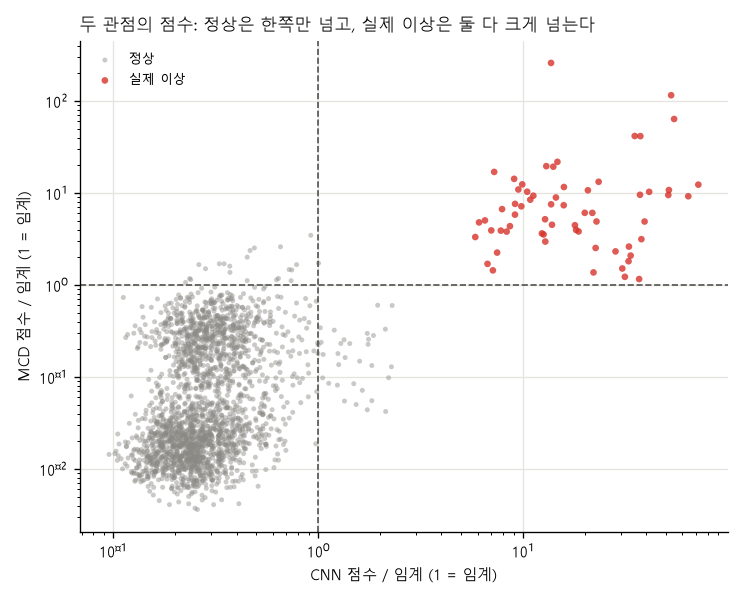

In [13]:
E.plot_quadrant(real, FIG); display(Image(FIG / "quadrant.png"))

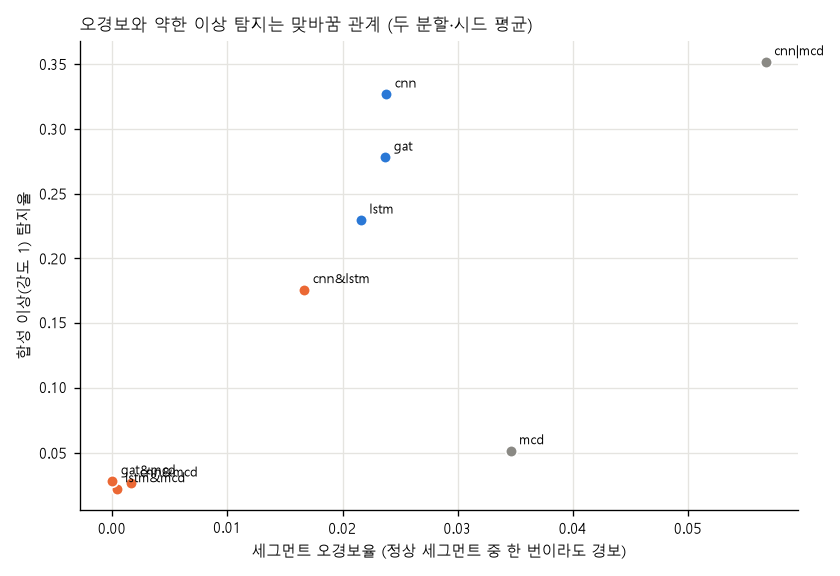

In [14]:
E.plot_tradeoff(cv[cv["model"].isin(["cnn", "lstm", "gat", "mcd", "cnn&mcd", "lstm&mcd", "gat&mcd", "cnn|mcd", "cnn&lstm"])], FIG)
display(Image(FIG / "tradeoff.png"))

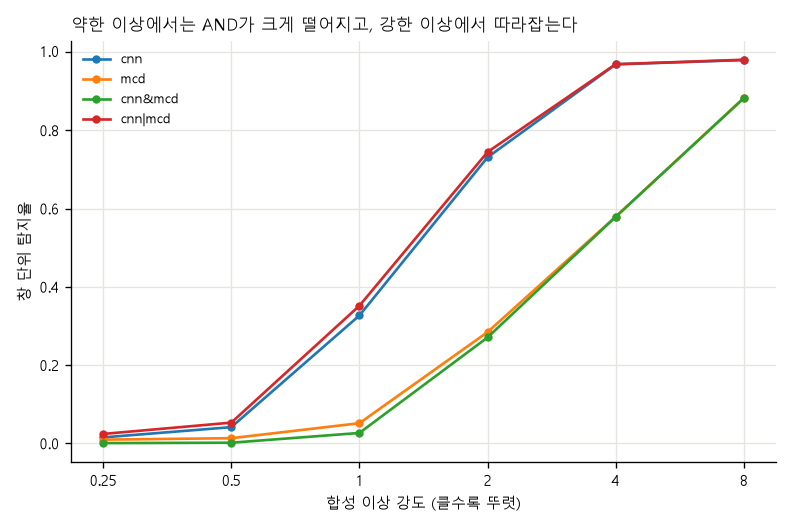

In [15]:
E.plot_strength(cv, FIG, ["cnn", "mcd", "cnn&mcd", "cnn|mcd"]); display(Image(FIG / "strength.png"))

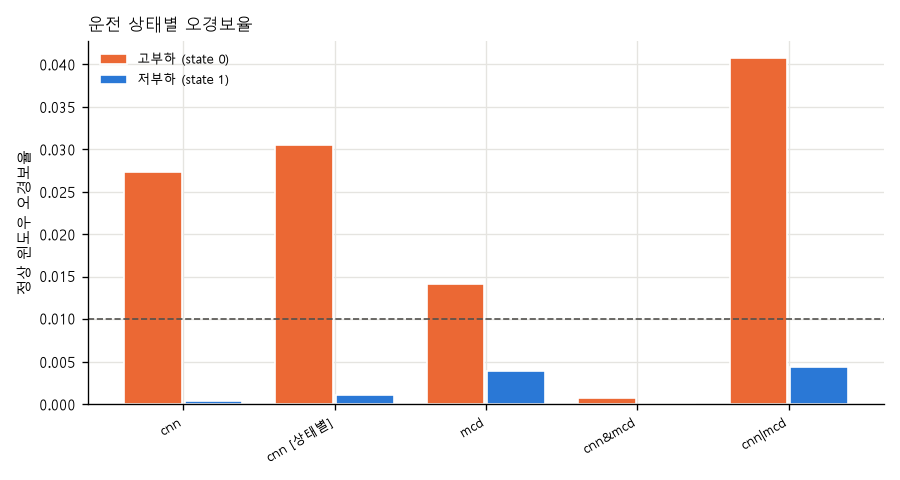

In [16]:
E.plot_state(cv, FIG, ["cnn", "cnn [상태별]", "mcd", "cnn&mcd", "cnn|mcd"]); display(Image(FIG / "state_fpr.png"))

## 9. 오류 사례 (FP·FN)

경보 규칙별로 오경보 세그먼트(FP)와 미탐 이상 세그먼트(FN)를 모은다. 조건별 집중은 `reports/28_model_ensemble_JIW.md`와 31 오류분석에서 다룬다.

In [17]:
errs = []
for name in ["cnn", "mcd", "cnn&mcd", "cnn|mcd"]:
    z = E.rule_z(real, name)
    d = real.assign(_hit=z > 1)
    for (sp, k, sd), g in d.groupby(E.KEYS):
        n = g[g["label"] == 0].groupby("seg_uid")["_hit"].agg(["sum", "size"])
        st = g[g["label"] == 0].groupby("seg_uid")["state"].first()
        for u, r in n[n["sum"] > 0].iterrows():
            errs.append({"rule": name, "split": sp, "fold": k, "seed": sd, "type": "FP", "seg_uid": u, "n_exceed": int(r["sum"]),
                         "n_windows": int(r["size"]), "state": B.STATE_NAME.get(st[u], "")})
        o = g[g["label"] == 1].groupby("seg_uid")[["_hit", "vib_grade", "cur_grade"]].agg({"_hit": "any", "vib_grade": "first", "cur_grade": "first"})
        for u, r in o[~o["_hit"]].iterrows():
            errs.append({"rule": name, "split": sp, "fold": k, "seed": sd, "type": "FN", "seg_uid": u,
                         "vib_grade": r["vib_grade"], "cur_grade": r["cur_grade"]})
err = pd.DataFrame(errs)
err.to_csv(RES / "error_cases.csv", index=False)
real[["split", "fold", "seed", "seg_uid", "t_start", "label", "state", "est_state"] + [f"s_{m}" for m in E.ALL_MODELS] + [f"thr_g_{m}" for m in E.ALL_MODELS]
     ].to_csv(RES / "scores.csv", index=False)
fp = err[err["type"] == "FP"].groupby(["rule", "split", "seed"]).size().unstack("seed", fill_value=0).reindex(columns=list(SEEDS), fill_value=0).mean(axis=1).unstack().round(1)
print("FP 세그먼트 수 (시드 평균, 분할 안 합계)"); display(fp)
print("FN(미탐) 이상 세그먼트 수: 규칙별", err[err["type"] == "FN"].groupby("rule").size().to_dict() or "전 규칙 0건")

FP 세그먼트 수 (시드 평균, 분할 안 합계)


split,group_kfold_seg,time_block
rule,,
cnn,12.7,6.3
cnn&mcd,1.0,0.3
cnn|mcd,28.7,17.0
mcd,17.0,11.0


FN(미탐) 이상 세그먼트 수: 규칙별 전 규칙 0건


## 10. 해석

발견 → 시사점 → 활용 아이디어는 `reports/28_model_ensemble_JIW.md`에 정리했다.